### Smart-Stock TrOCR — Kaggle

### Setup & Paths (pip installs + env)

In [1]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install -q transformers==5.0.0 datasets evaluate jiwer albumentations
!pip install -q "peft==0.13.2"
!pip install -q "torchao>=0.16.0"
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cud

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from pathlib import Path

INPUT_DIR   = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")

# ── Dataset — v4 filtered clean dataset ──────────────────────────────────────
DATASET_DIR = Path("/kaggle/input/datasets/maazahmad69/smart-stock-dataset-v4/smart_stock_dataset_v4")

# ── WildReceipt raw ───────────────────────────────────────────────────────────
WILDRECEIPT_DIR = Path("/kaggle/input/datasets/maazahmad69/wild-receipt/wildreceipt")

# ── Model weights — 0.0631 CER best model ────────────────────────────────────
# Using trocr-smart-stock-model which has confirmed model.safetensors
MODEL_INPUT = Path("/kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock-best/trocr-smart-stock-best")

# ── Resume checkpoint-31665 from smart-stock-model-data (slug unchanged) ─────
# INPUT_CHECKPOINT_DIR = Path("/kaggle/input/datasets/maazahmad69/smart-stock-model-data/trocr-smart-stock/checkpoint-31665")
INPUT_CHECKPOINT_DIR = Path("/kaggle/input/datasets/maazahmad69/smart-stock-model-data/trocr-smart-stock/checkpoint-31665")

# ── Output dirs ───────────────────────────────────────────────────────────────
CHECKPOINT_DIR = WORKING_DIR / "trocr-smart-stock"
BEST_MODEL_DIR = WORKING_DIR / "trocr-smart-stock-best"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset dir     : {DATASET_DIR}")
print(f"WildReceipt dir : {WILDRECEIPT_DIR}")
print(f"Model input     : {MODEL_INPUT}")
print(f"Checkpoints     : {CHECKPOINT_DIR}")
print(f"Best model      : {BEST_MODEL_DIR}")

for f in ["config.json", "model.safetensors", "generation_config.json"]:
    exists = (MODEL_INPUT / f).exists()
    print(f"  {'✅' if exists else '❌'} {f}")

# Verify checkpoint exists
lora_path = INPUT_CHECKPOINT_DIR / "lora_adapter"
direct_path = INPUT_CHECKPOINT_DIR / "adapter_config.json"
print(f"\n  {'✅' if lora_path.exists() else '❌'} checkpoint lora_adapter")
print(f"  {'✅' if direct_path.exists() else '❌'} checkpoint adapter_config.json")

Dataset dir     : /kaggle/input/datasets/maazahmad69/smart-stock-dataset-v4/smart_stock_dataset_v4
WildReceipt dir : /kaggle/input/datasets/maazahmad69/wild-receipt/wildreceipt
Model input     : /kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock-best/trocr-smart-stock-best
Checkpoints     : /kaggle/working/trocr-smart-stock
Best model      : /kaggle/working/trocr-smart-stock-best
  ✅ config.json
  ✅ model.safetensors
  ✅ generation_config.json

  ✅ checkpoint lora_adapter
  ✅ checkpoint adapter_config.json


In [3]:
# Paste in a scratch cell to confirm paths before committing
lora = Path("/kaggle/input/datasets/maazahmad69/smart-stock-model-data/trocr-smart-stock/checkpoint-31665/lora_adapter")
direct = Path("/kaggle/input/datasets/maazahmad69/smart-stock-model-data/trocr-smart-stock/checkpoint-31665/adapter_config.json")
print(f"lora_adapter exists   : {lora.exists()}")
print(f"adapter_config exists : {direct.exists()}")

lora_adapter exists   : True
adapter_config exists : True


#### **CORD's ground_truth** field is a raw JSON string. Parse it and construct a flat text target from the menu array.

In [4]:
import json
from collections import defaultdict
from PIL import Image

def extract_cord_crops(image: Image.Image, ground_truth_str: str) -> list:
    """
    Extract line-level crops from a CORD receipt image.

    CORD's ground_truth is a raw JSON string. Bounding boxes are in
    valid_line[].words[].quad — NOT in gt_parse.menu.
    Each group_id in valid_line = one logical receipt line.
    We group words by group_id, merge their quads into one bbox, crop it,
    and use the joined word texts as the OCR target.
    Only menu.* categories are kept (skip total, tax, header lines).

    Returns list of (cropped_PIL_image, text) pairs.
    One CORD receipt → ~8–12 crops.
    """
    try:
        data = json.loads(ground_truth_str)
    except (json.JSONDecodeError, AttributeError):
        return []

    valid_lines = data.get("valid_line", [])
    if not valid_lines:
        return []

    groups = defaultdict(list)
    for line in valid_lines:
        groups[line["group_id"]].append(line)

    w, h = image.size
    crops = []

    for gid, lines in groups.items():
        if not any(l.get("category", "").startswith("menu.") for l in lines):
            continue

        all_words, all_xs, all_ys = [], [], []
        for line in lines:
            for word in line.get("words", []):
                text = word.get("text", "").strip()
                if text:
                    all_words.append(text)
                q = word.get("quad", {})
                if q:
                    all_xs += [q.get("x1",0), q.get("x2",0), q.get("x3",0), q.get("x4",0)]
                    all_ys += [q.get("y1",0), q.get("y2",0), q.get("y3",0), q.get("y4",0)]

        if not all_words or not all_xs:
            continue

        text = " ".join(all_words)
        x1, y1 = max(0, min(all_xs)), max(0, min(all_ys))
        x2, y2 = min(w, max(all_xs)), min(h, max(all_ys))
        if x2 <= x1 or y2 <= y1:
            continue

        crops.append((image.crop((x1, y1, x2, y2)), text))

    return crops

### **SROIE** Text Reconstruction
#### SROIE has bboxes per word. Group words by Y-coordinate (within 15px = same line), merge bounding boxes per line, crop each line region.

In [5]:
def extract_sroie_crops(image: Image.Image, words: list, bboxes: list) -> list:
    """
    Group SROIE words into lines by Y-coordinate proximity (15px tolerance).
    Each line bbox is cropped and paired with its joined text.
    SROIE has bboxes per word — no pre-grouped lines.

    Returns list of (cropped_PIL_image, text) pairs.
    """
    if not words or not bboxes:
        return []

    items = sorted(zip(words, bboxes), key=lambda x: x[1][1])

    lines = []
    current_words, current_boxes = [items[0][0]], [items[0][1]]
    for word, box in items[1:]:
        if abs(box[1] - current_boxes[-1][1]) <= 15:
            current_words.append(word)
            current_boxes.append(box)
        else:
            lines.append((current_words, current_boxes))
            current_words, current_boxes = [word], [box]
    lines.append((current_words, current_boxes))

    w, h = image.size
    crops = []
    for line_words, line_boxes in lines:
        text = " ".join(line_words).strip()
        if not text:
            continue
        x1 = max(0, min(b[0] for b in line_boxes))
        y1 = max(0, min(b[1] for b in line_boxes))
        x2 = min(w, max(b[2] for b in line_boxes))
        y2 = min(h, max(b[3] for b in line_boxes))
        if x2 <= x1 or y2 <= y1:
            continue
        crops.append((image.crop((x1, y1, x2, y2)), text))
    return crops

### WildReceipt Extractor 

In [6]:
import json

# Labels to EXCLUDE from WildReceipt:
# 0  = empty string / illegible text
# 25 = catch-all "other" (terminal IDs, legal footnotes, thank-you messages, promo text)
# All other labels (1=store name, 3=address, 5=phone, 7=date, 9=time,
# 11=item name, 13=quantity, 14=count, 15=item price, 17=subtotal,
# 18=subtotal label, 19=tax amount, 20=tax label, 22=tip, 23=total,
# 24=total label) are included.
WILDRECEIPT_EXCLUDE = {0, 25}

def extract_wildreceipt_crops(annotation_file: Path) -> list:
    """
    Parse a WildReceipt annotation file (one JSON object per line).
    Each annotation becomes its own crop — no line grouping.

    Why no grouping: WildReceipt has two-column layouts (item names left,
    prices right) with nearly identical Y coordinates per row. Y-proximity
    grouping merged columns into nonsense crops, corrupting ~33% of train data
    and causing CER regression from 0.088 → 0.339.

    Per-annotation cropping is also closer to TrOCR's pretraining distribution
    (single word/phrase level crops) than multi-word line crops.

    Each annotation box: [x1,y1, x2,y1, x2,y2, x1,y2] clockwise from top-left.
    Returns list of (PIL.Image, text) pairs.
    """
    crops = []

    with open(annotation_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue

            img_path = WILDRECEIPT_DIR / record["file_name"]
            if not img_path.exists():
                continue

            try:
                image = Image.open(img_path).convert("RGB")
            except Exception:
                continue

            img_w, img_h = image.size

            for ann in record["annotations"]:
                # Skip excluded labels and empty text
                if ann["label"] in WILDRECEIPT_EXCLUDE:
                    continue
                text = ann.get("text", "").strip()
                if not text:
                    continue

                # Box: [x1,y1, x2,y1, x2,y2, x1,y2]
                box = ann["box"]
                xs = [box[0], box[2], box[4], box[6]]
                ys = [box[1], box[3], box[5], box[7]]

                x1 = max(0, int(min(xs)))
                y1 = max(0, int(min(ys)))
                x2 = min(img_w, int(max(xs)))
                y2 = min(img_h, int(max(ys)))

                # Skip degenerate crops — beam search hangs on these
                if x2 <= x1 or y2 <= y1:
                    continue
                if (x2 - x1) < 4 or (y2 - y1) < 4:
                    continue

                crops.append((image.crop((x1, y1, x2, y2)), text))

    return crops

### Combined Dataset Builder
OOM fix: Images encoded to PNG bytes immediately. Line crops: Each receipt yields multiple (crop, text) pairs. SROIE 2x weighting: SROIE train concatenated twice.

In [7]:
import io
import json
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from PIL import Image

# ── Helpers ───────────────────────────────────────────────────────────────────

def pil_to_bytes(img: Image.Image) -> bytes:
    """Encode PIL image to PNG bytes immediately — prevents RAM accumulation."""
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="PNG")
    return buf.getvalue()

def iter_to_dataset(iterator) -> Dataset:
    """
    Convert iterator of (PIL Image, text) tuples into a HuggingFace Dataset.
    Encodes each image to bytes immediately — never holds multiple PIL objects in RAM.
    """
    img_bytes, texts = [], []
    for img, text in iterator:
        img_bytes.append(pil_to_bytes(img))
        texts.append(text)
    return Dataset.from_dict({"image_bytes": img_bytes, "text": texts})

# ── Combined dataset builder ──────────────────────────────────────────────────

DATASET_SAVE = DATASET_DIR  # points to smart-stock-dataset-v3 — loads if exists, builds if not

WR_TEST_KEEP = 1000  # cap WildReceipt test crops; remainder folds into train

def build_and_save_dataset():
    if DATASET_SAVE.exists():
        print(f"Dataset found at {DATASET_SAVE} — loading from disk...")
        return DatasetDict.load_from_disk(str(DATASET_SAVE))

    print("Building v3 line-crop dataset (CORD + SROIE + WildReceipt)...")

    # ── CORD ──────────────────────────────────────────────────────────────────
    print("Loading CORD...")
    cord = load_dataset("naver-clova-ix/cord-v2")

    def cord_iter(split):
        for ex in cord[split]:
            for crop, text in extract_cord_crops(ex["image"], ex["ground_truth"]):
                yield crop, text

    cord_train      = iter_to_dataset(cord_iter("train"))
    cord_validation = iter_to_dataset(cord_iter("validation"))
    cord_test       = iter_to_dataset(cord_iter("test"))
    print(f"  CORD  train: {len(cord_train)} | val: {len(cord_validation)} | test: {len(cord_test)}")
    del cord  # free RAM before loading next dataset

    # ── SROIE ─────────────────────────────────────────────────────────────────
    print("Loading SROIE...")
    sroie = load_dataset("sizhkhy/SROIE")

    def sroie_iter(split):
        for ex in sroie[split]:
            for crop, text in extract_sroie_crops(ex["images"], ex["words"], ex["bboxes"]):
                yield crop, text

    sroie_train = iter_to_dataset(sroie_iter("train"))
    sroie_test  = iter_to_dataset(sroie_iter("test"))
    print(f"  SROIE train: {len(sroie_train)} | test: {len(sroie_test)}")
    del sroie

    # ── WildReceipt ───────────────────────────────────────────────────────────
    print("Loading WildReceipt...")
    wr_train_crops = extract_wildreceipt_crops(WILDRECEIPT_DIR / "train.txt")
    wr_test_crops  = extract_wildreceipt_crops(WILDRECEIPT_DIR / "test.txt")

    wr_train_raw = iter_to_dataset(iter(wr_train_crops))
    wr_test_raw  = iter_to_dataset(iter(wr_test_crops))
    print(f"  WildReceipt raw — train: {len(wr_train_raw)} | test: {len(wr_test_raw)}")

    # 90% train / 10% val split from WildReceipt train.txt crops
    wr_train_split = wr_train_raw.train_test_split(test_size=0.1, seed=42)
    wr_train_final = wr_train_split["train"]
    wr_val         = wr_train_split["test"]
    print(f"  WildReceipt train (after val split): {len(wr_train_final)} | val: {len(wr_val)}")

    # Cap test.txt crops at WR_TEST_KEEP (1000), move remainder to train
    # Reason: 5,103 test crops * beam search = hours of eval time (killed prior session)
    if len(wr_test_raw) > WR_TEST_KEEP:
        wr_test_split    = wr_test_raw.train_test_split(test_size=WR_TEST_KEEP, seed=42)
        wr_test_final    = wr_test_split["test"]
        wr_test_to_train = wr_test_split["train"]
    else:
        wr_test_final    = wr_test_raw
        wr_test_to_train = None

    print(f"  WildReceipt test kept: {len(wr_test_final)} | moved to train: {len(wr_test_to_train) if wr_test_to_train else 0}")

    # ── Combine ───────────────────────────────────────────────────────────────
    # SROIE 2x weighted in train — more English receipt signal vs CORD's Indonesian
    # Excess WildReceipt test crops folded into train (free data)
    train_parts = [cord_train, sroie_train, sroie_train, wr_train_final]
    if wr_test_to_train:
        train_parts.append(wr_test_to_train)

    dataset_dict = DatasetDict({
        "train":      concatenate_datasets(train_parts),
        "validation": concatenate_datasets([cord_validation, wr_val]),
        "test":       concatenate_datasets([cord_test, sroie_test, wr_test_final]),
    })

    # Save to working dir — download and upload as Kaggle dataset smart-stock-dataset-v3
    save_path = WORKING_DIR / "smart_stock_dataset_v3"
    dataset_dict.save_to_disk(str(save_path))
    print(f"\n✅ Saved to {save_path}")
    print(f"   Train      : {len(dataset_dict['train'])}")
    print(f"   Validation : {len(dataset_dict['validation'])}")
    print(f"   Test       : {len(dataset_dict['test'])}")
    return dataset_dict

combined_dataset = build_and_save_dataset()

Dataset found at /kaggle/input/datasets/maazahmad69/smart-stock-dataset-v4/smart_stock_dataset_v4 — loading from disk...


### Dataset filter

In [8]:
# # ── Dataset Filter → smart-stock-dataset-v4 ───────────────────────────────────
# # Run AFTER inspecting crop_sample_*.png outputs from the diagnostic cell.
# # Set MIN_WIDTH and MIN_HEIGHT based on what you saw.
# # Also applies non-food label blocklist to remove header/footer WildReceipt noise.

# import io, re
# from PIL import Image
# from datasets import DatasetDict

# # ── SET THESE based on diagnostic output ──────────────────────────────────────
# MIN_WIDTH  = 50   # change after inspecting the PNG grids
# MIN_HEIGHT = 10   # change after inspecting the PNG grids
# MIN_LABEL_CHARS = 2  # drop single-char labels ('2', 'P', etc.)
# # ─────────────────────────────────────────────────────────────────────────────

# # Non-food receipt tokens that slipped through WildReceipt annotation.
# # These cause hallucination — the model sees similar crops and generates
# # entire receipt footers instead of the actual text.
# # Conservative list — only unambiguous non-food header/footer tokens.
# NON_FOOD_BLOCKLIST = {
#     "tax", "salestax", "subtotal", "total", "date", "time", "receipt",
#     "invoice", "change", "cash", "card", "payment", "balance", "tip",
#     "thank you", "gst", "vat", "hst", "pst", "discount", "void",
#     "cashier", "terminal", "ref", "auth", "batch",
#     # Short receipt metadata tokens
#     "ti:", "p:", "ht", "wef", "no.", "no:", "tel:", "tel",
# }

# def should_keep(sample) -> bool:
#     # 1. Size filter
#     try:
#         img = Image.open(io.BytesIO(sample["image_bytes"]))
#         w, h = img.size
#         if w < MIN_WIDTH or h < MIN_HEIGHT:
#             return False
#     except Exception:
#         return False  # corrupt image bytes

#     # 2. Label length filter
#     text = sample["text"].strip()
#     if len(text) < MIN_LABEL_CHARS:
#         return False

#     # 3. Non-food blocklist — exact match on lowercased label
#     # Using exact match only (not substring) to avoid false positives
#     # e.g. "TOTAL CORNFLAKES 2 3.99" should NOT be filtered
#     if text.lower() in NON_FOOD_BLOCKLIST:
#         return False

#     return True

# # ── Apply filter to all splits ────────────────────────────────────────────────
# print(f"Filter thresholds: width≥{MIN_WIDTH}, height≥{MIN_HEIGHT}, label≥{MIN_LABEL_CHARS} chars")
# print(f"Blocklist entries: {len(NON_FOOD_BLOCKLIST)}")
# print()

# filtered = {}
# for split in ["train", "validation", "test"]:
#     original = combined_dataset[split]

#     # Build keep indices manually — avoids dataset.filter() cache write to /kaggle/input/
#     keep_indices = []
#     for i in range(len(original)):
#         if should_keep(original[i]):
#             keep_indices.append(i)

#     kept    = original.select(keep_indices)
#     removed = len(original) - len(kept)
#     filtered[split] = kept
#     print(f"  {split:12s} | original={len(original):6d} | kept={len(kept):6d} | removed={removed:5d} ({100*removed/len(original):.1f}%)")

# filtered_dataset = DatasetDict(filtered)

# # ── Save to working dir ───────────────────────────────────────────────────────
# SAVE_PATH = WORKING_DIR / "smart_stock_dataset_v4"
# filtered_dataset.save_to_disk(str(SAVE_PATH))

# print(f"\n✅ Saved to {SAVE_PATH}")
# print(f"   Train      : {len(filtered_dataset['train'])}")
# print(f"   Validation : {len(filtered_dataset['validation'])}")
# print(f"   Test       : {len(filtered_dataset['test'])}")
# print("\nNext: download smart_stock_dataset_v4 from Kaggle output and upload as new dataset version.")
# print("Then update DATASET_DIR in Cell 2 to point to v4.")

### Size Distribution Diagnostic

In [9]:
# # ── Crop Size Diagnostic ──────────────────────────────────────────────────────
# # Before filtering anything, inspect the size distribution across all splits.
# # Shows: size bucket counts, samples removed at different thresholds, and saves
# # a grid of sample crops at each size range for manual visual inspection.
# # Run this BEFORE the filter cell — decide threshold based on output.

# import io, os
# from PIL import Image, ImageDraw, ImageFont
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import numpy as np

# DIAG_SPLIT = "train"  # train has the most samples, most representative
# samples = combined_dataset[DIAG_SPLIT]
# print(f"Inspecting {DIAG_SPLIT} split: {len(samples)} samples")

# # ── Collect all sizes ─────────────────────────────────────────────────────────
# widths, heights, areas, labels_list = [], [], [], []

# for i in range(len(samples)):
#     s = samples[i]
#     img = Image.open(io.BytesIO(s["image_bytes"]))
#     w, h = img.size
#     widths.append(w)
#     heights.append(h)
#     areas.append(w * h)
#     labels_list.append(s["text"])

# widths  = np.array(widths)
# heights = np.array(heights)
# areas   = np.array(areas)

# # ── Size bucket distribution ──────────────────────────────────────────────────
# print("\n── Width distribution ───────────────────────────────────")
# w_buckets = [0, 10, 20, 30, 50, 100, 200, 500, 99999]
# w_labels  = ["<10", "10-20", "20-30", "30-50", "50-100", "100-200", "200-500", ">500"]
# for i in range(len(w_labels)):
#     mask  = (widths >= w_buckets[i]) & (widths < w_buckets[i+1])
#     count = mask.sum()
#     bar   = "█" * int(40 * count / len(widths))
#     print(f"  w {w_labels[i]:8s} | {count:5d} ({100*count/len(widths):4.1f}%) {bar}")

# print("\n── Height distribution ──────────────────────────────────")
# h_buckets = [0, 8, 10, 15, 20, 30, 50, 99999]
# h_labels  = ["<8", "8-10", "10-15", "15-20", "20-30", "30-50", ">50"]
# for i in range(len(h_labels)):
#     mask  = (heights >= h_buckets[i]) & (heights < h_buckets[i+1])
#     count = mask.sum()
#     bar   = "█" * int(40 * count / len(heights))
#     print(f"  h {h_labels[i]:8s} | {count:5d} ({100*count/len(heights):4.1f}%) {bar}")

# # ── How many samples removed at different thresholds ─────────────────────────
# print("\n── Samples removed at different (min_w, min_h) thresholds ──")
# print(f"  {'Threshold':20s} | {'Removed':>8s} | {'Remaining':>10s} | {'% Removed':>10s}")
# thresholds = [(10,5), (20,8), (30,10), (40,12), (50,15), (64,16)]
# for min_w, min_h in thresholds:
#     removed   = ((widths < min_w) | (heights < min_h)).sum()
#     remaining = len(widths) - removed
#     print(f"  w≥{min_w:<4d} h≥{min_h:<4d}          | {removed:>8d} | {remaining:>10d} | {100*removed/len(widths):>9.2f}%")

# # ── Save sample crops from each size range for visual inspection ──────────────
# # Saves a PNG grid of 5 crops from each width bucket to /kaggle/working/
# print("\n── Saving sample crop grids to /kaggle/working/ ─────────────")

# size_ranges = [
#     ("tiny",   widths <  20),
#     ("small",  (widths >= 20) & (widths < 50)),
#     ("medium", (widths >= 50) & (widths < 150)),
#     ("large",  widths >= 150),
# ]

# for range_name, mask in size_ranges:
#     indices = np.where(mask)[0][:8]  # first 8 samples in this range
#     if len(indices) == 0:
#         print(f"  {range_name}: no samples")
#         continue

#     fig, axes = plt.subplots(2, 4, figsize=(16, 5))
#     fig.suptitle(f"Crop size range: {range_name}", fontsize=14)
#     axes = axes.flatten()

#     for plot_i, sample_idx in enumerate(indices):
#         s   = samples[int(sample_idx)]
#         img = Image.open(io.BytesIO(s["image_bytes"])).convert("RGB")
#         w, h = img.size
#         axes[plot_i].imshow(img)
#         axes[plot_i].set_title(
#             f"{w}x{h}px\n{s['text'][:30]!r}",
#             fontsize=7, wrap=True
#         )
#         axes[plot_i].axis("off")

#     for j in range(len(indices), len(axes)):
#         axes[j].axis("off")

#     out_path = f"/kaggle/working/crop_sample_{range_name}.png"
#     plt.tight_layout()
#     plt.savefig(out_path, dpi=100, bbox_inches="tight")
#     plt.close()
#     print(f"  Saved: {out_path} ({len(indices)} samples shown)")

# print("\nDone. Check the 4 PNG files in /kaggle/working/ to visually inspect crops.")
# print("Decide threshold based on what you see, then run the filter cell.")

In [10]:
# import json
# import io
# from PIL import Image

# # Pick 3 WildReceipt images and show crop count + text per crop
# with open(WILDRECEIPT_DIR / "train.txt") as f:
#     lines = [l.strip() for l in f if l.strip()][:3]

# for line in lines:
#     record = json.loads(line)
#     img = Image.open(WILDRECEIPT_DIR / record["file_name"]).convert("RGB")
#     img_w, img_h = img.size
#     y_tol = max(10, int(img_h * 0.02))
    
#     valid = [a for a in record["annotations"]
#              if a["label"] not in {0, 25} and a.get("text","").strip()]
    
#     print(f"\nImage: {record['file_name']} ({img_w}×{img_h}), y_tol={y_tol}")
#     print(f"Valid annotations: {len(valid)}")
#     for a in valid:
#         box = a["box"]
#         ys = [box[1], box[3], box[5], box[7]]
#         cy = (min(ys) + max(ys)) / 2
#         print(f"  cy={cy:.0f}  text='{a['text']}'  label={a['label']}")

#### **Augmentation**
Apply augmentation only to training images, inline during the preprocess_trocr step.

In [11]:
import albumentations as A
import cv2
import numpy as np
from PIL import Image, ImageOps

receipt_augmentation = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=(-0.4, 0.15), p=0.6),  # thermal fade simulation
    A.GaussNoise(p=0.5),                                                 # scanner noise
    A.Rotate(limit=8, border_mode=cv2.BORDER_REPLICATE, p=0.5),         # crumple/tilt
    A.Perspective(scale=(0.02, 0.08), p=0.4),                           # phone photo angle
    A.MotionBlur(blur_limit=5, p=0.3),                                  # shaky photo
    A.ImageCompression(p=0.5),                                           # JPEG artifact
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),                           # focus blur
    A.RandomShadow(p=0.2),                                               # shadow on receipt
])

def apply_augmentation(pil_image: Image.Image) -> Image.Image:
    """Pad tiny line crops to min 32px height, then augment."""
    pil_image = pil_image.convert("RGB")
    if pil_image.height < 32:
        pad = 32 - pil_image.height
        pil_image = ImageOps.expand(pil_image, border=(0, pad//2, 0, pad - pad//2), fill=255)
    img_np = np.array(pil_image)
    augmented = receipt_augmentation(image=img_np)["image"]
    return Image.fromarray(augmented)

### Preprocessing Function

In [12]:
import io
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")

def preprocess_trocr(example, augment: bool = False):
    """
    Preprocess a single (image_bytes, text) example at access time.
    Returns dict with pixel_values (tensor) and labels (tensor).
    Padding tokens replaced with -100 so loss ignores them.
    """
    image = Image.open(io.BytesIO(example["image_bytes"])).convert("RGB")

    if augment:
        image = apply_augmentation(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values

    labels = processor.tokenizer(
        example["text"],
        padding="max_length",
        max_length=128,
        truncation=True,
    ).input_ids

    labels = [
        t if t != processor.tokenizer.pad_token_id else -100
        for t in labels
    ]

    return {
        "pixel_values": pixel_values.squeeze(),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


class TrOCRDataset(TorchDataset):
    """
    On-the-fly preprocessing — processes each example at access time.
    Replaces .map() which caused either:
      - OOM (keep_in_memory=True on 46k examples)
      - OSError Errno 28 (cache writing to read-only /kaggle/input/)
    Zero disk usage, zero RAM accumulation, full dataset used.
    Compatible with Seq2SeqTrainer.

    NOTE: This is a PyTorch Dataset — it has no .select() method.
    For Optuna subset selection, use combined_dataset["train"].select(...)
    (the HuggingFace dataset) and then wrap in TrOCRDataset().
    """
    def __init__(self, hf_dataset, augment: bool = False):
        self.data    = hf_dataset
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return preprocess_trocr(self.data[idx], augment=self.augment)


train_dataset = TrOCRDataset(combined_dataset["train"],      augment=True)
val_dataset   = TrOCRDataset(combined_dataset["validation"], augment=False)
test_dataset  = TrOCRDataset(combined_dataset["test"],       augment=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Train: 50657 | Val: 1800 | Test: 8720


### Model Setup

In [13]:
from pathlib import Path
from transformers import VisionEncoderDecoderModel
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

# INPUT_CHECKPOINT_DIR already defined in Cell 1
INPUT_CHECKPOINT_DIR = Path("/kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock/trocr-smart-stock/checkpoint-51348")

# Load base model from stored best weights
base_model = VisionEncoderDecoderModel.from_pretrained(str(MODEL_INPUT))

# Freeze entire encoder first, then unfreeze top 2 ViT blocks (indices 10 and 11)
# ViT has 12 blocks (0-11). Top 2 hold highest-level visual representations —
# most likely to benefit from receipt-domain adaptation.
# Lower blocks stay frozen — no need to re-learn low-level patch/texture features.
for param in base_model.encoder.parameters():
    param.requires_grad = False

for block_idx in [10, 11]:
    for param in base_model.encoder.encoder.layer[block_idx].parameters():
        param.requires_grad = True

encoder_trainable = sum(p.numel() for p in base_model.encoder.parameters() if p.requires_grad)
encoder_total     = sum(p.numel() for p in base_model.encoder.parameters())
print(f"Encoder trainable params (blocks 10+11): {encoder_trainable:,} / {encoder_total:,}")

# ── Checkpoint resume priority ────────────────────────────────────────────────
# 1. /kaggle/working/trocr-smart-stock  (current session checkpoints, most recent)
# 2. checkpoint-51348 from input dataset (uploaded from prior session — fallback)
# 3. Fresh LoRA (no prior checkpoint found)

def find_lora_checkpoints(directory: Path):
    """Find checkpoints with LoRA adapter weights in either format."""
    return sorted([
        ckpt for ckpt in directory.glob("checkpoint-*")
        if (ckpt / "lora_adapter").exists() or (ckpt / "adapter_config.json").exists()
    ])

working_checkpoints = find_lora_checkpoints(CHECKPOINT_DIR)

if working_checkpoints:
    latest = working_checkpoints[-1]
    adapter_path = latest / "lora_adapter" if (latest / "lora_adapter").exists() else latest
    model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=True)
    print(f"Resumed from working dir: {adapter_path}")

elif INPUT_CHECKPOINT_DIR.exists() and (
    (INPUT_CHECKPOINT_DIR / "lora_adapter").exists() or
    (INPUT_CHECKPOINT_DIR / "adapter_config.json").exists()
):
    adapter_path = INPUT_CHECKPOINT_DIR / "lora_adapter" if (INPUT_CHECKPOINT_DIR / "lora_adapter").exists() else INPUT_CHECKPOINT_DIR
    model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=True)
    print(f"Resumed from input dir: {adapter_path}")

else:
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules=["q_proj", "v_proj"],
        bias="none",
    )
    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()
    print("No adapter checkpoint found — fresh LoRA applied")

# Print total trainable params (encoder blocks + LoRA)
total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable params: {total_trainable:,}")

# Required decoder config
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

# Generation config
model.generation_config.eos_token_id   = processor.tokenizer.sep_token_id
model.generation_config.early_stopping = True
model.generation_config.length_penalty = 1.0
model.generation_config.num_beams      = 4
# no_repeat_ngram_size deliberately not set — receipt text has legitimate
# repetitions (e.g. "60.000 60.000") that ngram blocking incorrectly suppresses

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Encoder trainable params (blocks 10+11): 14,171,136 / 86,653,440
Resumed from input dir: /kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock/trocr-smart-stock/checkpoint-51348/lora_adapter
Total trainable params: 1,523,712


#### collate_fn

Standalone cell — extracted from the Optuna block so it's always available even when Optuna is commented out.

In [14]:
def collate_fn(batch):
    """
    Custom collator for TrOCR.
    pixel_values and labels are tensors returned by TrOCRDataset.__getitem__.
    torch.stack combines them into batches for the Trainer.
    """
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels       = torch.stack([item["labels"]       for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

### Training Arguments
Block A — OLD CONFIG (fully commented out, do not use)


Kept for reference only. This was the config from Kaggle run 1 (lr=1.695e-4, cosine scheduler). Superseded by Block B below.

In [15]:
# from transformers import Seq2SeqTrainingArguments

# training_args = Seq2SeqTrainingArguments(
#     output_dir=str(CHECKPOINT_DIR),   # /kaggle/working/trocr-smart-stock

#     num_train_epochs=5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,

#     # Hardcoded from Optuna best (Trial 3 of latest run)
#     learning_rate=1.695e-4,
#     warmup_ratio=0.0866,
#     weight_decay=0.01,
#     lr_scheduler_type="cosine",
#     max_grad_norm=1.0,

#     eval_strategy="epoch",
#     save_strategy="steps",
#     save_steps=500,
#     load_best_model_at_end=False,
#     save_total_limit=5,

#     predict_with_generate=True,
#     generation_max_length=128,

#     fp16=True,
#     dataloader_num_workers=2,

#     logging_dir=str(WORKING_DIR / "logs"),
#     logging_steps=50,
#     log_level="info",
#     report_to="none",
# )

##### Technique 1 — Force single GPU + fix LR (most important, run first)

DataParallel doubled effective batch size silently. Forcing single GPU makes real training match Optuna's conditions exactly.

##### Block B — ACTIVE CONFIG (Technique 1: single GPU + correct LR)


This is the block that actually runs. os.environ line here is redundant (already set in Cell 1) but harmless.

In [16]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=str(CHECKPOINT_DIR),

    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,     # back to 1 — encoder is frozen, no OOM risk

    # Restored Optuna LR — valid for frozen encoder runs
    learning_rate=1.4824e-4,
    warmup_ratio=0.05,
    weight_decay=0.01,

    lr_scheduler_type="cosine_with_restarts",
    lr_scheduler_kwargs={"num_cycles": 1},

    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_cer",
    greater_is_better=False,
    save_total_limit=3,

    predict_with_generate=True,
    generation_max_length=128,

    fp16=True,
    dataloader_num_workers=2,

    logging_dir=str(WORKING_DIR / "logs"),
    logging_steps=50,
    log_level="info",
    report_to="none",
)

print(f"Effective batch size : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"GPU visible          : {os.environ.get('CUDA_VISIBLE_DEVICES')}")
print(f"LR                   : {training_args.learning_rate}")
print(f"Epochs               : {training_args.num_train_epochs}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Effective batch size : 8
GPU visible          : 0
LR                   : 0.00014824
Epochs               : 5


### Metrics

In [17]:
!pip install jiwer -q

In [18]:
import numpy as np
from jiwer import cer, wer

def compute_metrics(pred):
    """
    Compute CER and WER for Seq2SeqTrainer.
    Called at end of each eval epoch with generated token ids.
    """
    pred_ids   = pred.predictions
    labels_ids = pred.label_ids

    # pred_ids may be float logits (ndim=3) — argmax to get token ids
    if pred_ids.dtype != np.int64 and pred_ids.ndim == 3:
        pred_ids = np.argmax(pred_ids, axis=-1)

    # Clip to valid vocab range — prevents OverflowError during decode
    vocab_size = processor.tokenizer.vocab_size
    pred_ids   = np.clip(pred_ids, 0, vocab_size - 1)

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)

    # Replace -100 (padding mask) with pad token id before decoding
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    return {
        "cer": round(cer(label_str, pred_str), 4),
        "wer": round(wer(label_str, pred_str), 4),
    }

### Hyperparameter Search with **Optuna**
After the first clean training run with line crops, use Optuna (Bayesian optimization) via HuggingFace built-in hyperparameter_search to find optimal values.

#### Why commented: Current LR (1.4824e-4) was tuned by Optuna on a prior subset run. Running Optuna again costs ~3–4 hours of the 12-hour session before any real training starts.

When to uncomment: After a stable epoch 1 completes on v3 data and CER confirms ~0.088–0.092. If the LR feels off on the new dataset distribution, run Optuna in a separate dedicated session.

Config notes: n_trials=4 (not 10) — 4 trials × 1 epoch on 1/8 of 46,500 = ~5,800 examples per trial ≈ 45 min per trial ≈ 3 hr total. Fits in a dedicated session. predict_with_generate=True kept (unlike old v12 config) — we need CER not just loss to rank trials meaningfully.

In [19]:
# import gc
# import copy
# from transformers import Seq2SeqTrainer
# from peft import LoraConfig, get_peft_model, TaskType

# def optuna_hp_space(trial):
#     return {
#         "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-4, log=True),
#         "warmup_ratio":  trial.suggest_float("warmup_ratio", 0.0, 0.1),
#     }

# def model_init():
#     gc.collect()
#     torch.cuda.empty_cache()

#     m = VisionEncoderDecoderModel.from_pretrained(str(MODEL_INPUT))

#     for param in m.encoder.parameters():
#         param.requires_grad = False

#     lora_config = LoraConfig(
#         task_type=TaskType.SEQ_2_SEQ_LM,
#         r=16,
#         lora_alpha=32,
#         lora_dropout=0.05,
#         target_modules=["q_proj", "v_proj"],
#         bias="none",
#     )
#     m = get_peft_model(m, lora_config)

#     m.config.decoder_start_token_id = processor.tokenizer.cls_token_id
#     m.config.pad_token_id           = processor.tokenizer.pad_token_id
#     m.config.vocab_size             = m.config.decoder.vocab_size
#     m.generation_config.eos_token_id   = processor.tokenizer.sep_token_id
#     m.generation_config.early_stopping = True
#     m.generation_config.length_penalty = 1.0
#     m.generation_config.num_beams      = 4
#     # no_repeat_ngram_size removed — causes CER > 1.0 on receipt text
#     return m

# search_args = copy.deepcopy(training_args)
# search_args.num_train_epochs = 1
# search_args.predict_with_generate = True
# search_args.eval_accumulation_steps = 4
# search_args.dataloader_num_workers = 0
# search_args.per_device_train_batch_size = 4
# search_args.per_device_eval_batch_size = 4
# search_args.output_dir = str(WORKING_DIR / "optuna_search")
# search_args.save_strategy = "no"
# search_args.load_best_model_at_end = False
# search_args.eval_strategy = "epoch"
# search_args.logging_steps = 50

# # Use 1/8 of training data for speed — val capped at 200 samples
# search_val_hf = combined_dataset["validation"].select(range(min(200, len(combined_dataset["validation"]))))
# search_val = TrOCRDataset(search_val_hf, augment=False)

# search_hf = combined_dataset["train"].select(range(len(combined_dataset["train"]) // 8))
# search_train = TrOCRDataset(search_hf, augment=True)

# search_trainer = Seq2SeqTrainer(
#     model_init=model_init,
#     args=search_args,
#     train_dataset=search_train,
#     eval_dataset=search_val,
#     data_collator=collate_fn,
#     compute_metrics=compute_metrics,
# )

# best_run = search_trainer.hyperparameter_search(
#     direction="minimize",
#     backend="optuna",
#     hp_space=optuna_hp_space,
#     n_trials=4,
# )

# del search_trainer
# gc.collect()
# torch.cuda.empty_cache()

# print("Best hyperparameters:", best_run.hyperparameters)
# for k, v in best_run.hyperparameters.items():
#     setattr(training_args, k, v)
# training_args.predict_with_generate = True
# print("Updated training_args:", training_args.learning_rate, training_args.warmup_ratio)

### Trainer and Training

In [20]:
from transformers import Seq2SeqTrainer, TrainerCallback
import shutil

class LoRASaveCallback(TrainerCallback):
    """
    Saves LoRA adapter weights alongside each Trainer checkpoint.
    Without this, PEFT silently resets adapter weights on checkpoint reload.
    Saves to: checkpoint-{step}/lora_adapter/
    """
    def on_save(self, args, state, control, **kwargs):
        checkpoint_dir = Path(args.output_dir) / f"checkpoint-{state.global_step}"
        adapter_dir = checkpoint_dir / "lora_adapter"
        adapter_dir.mkdir(parents=True, exist_ok=True)
        kwargs["model"].save_pretrained(str(adapter_dir))
        print(f"LoRA adapter saved to {adapter_dir}")
        return control

print(f"LR: {training_args.learning_rate}")
print(f"Warmup ratio: {training_args.warmup_ratio}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")

# Remove stale checkpoints from prior bad runs (no lora_adapter subdir)
if CHECKPOINT_DIR.exists():
    for ckpt in CHECKPOINT_DIR.glob("checkpoint-*"):
        has_adapter = (ckpt / "lora_adapter").exists()
        if not has_adapter:
            shutil.rmtree(ckpt)
            print(f"Removed stale checkpoint (no LoRA adapter): {ckpt}")

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[LoRASaveCallback()],
)

# ── Clean-data run — NO checkpoint resume ─────────────────────────────────────
# Starting fresh from the 0.0687 merged model weights (loaded in Cell 8).
# Reason: optimizer state from checkpoint-51348 was computed on the noisy v3
# dataset. Resuming it would apply momentum from noisy-data gradients to a
# clean-data training run — counterproductive.
#
# If working-dir checkpoints exist from THIS session (mid-run restart),
# resume from those — they have correct clean-data optimizer state.
valid_checkpoints = sorted(CHECKPOINT_DIR.glob("checkpoint-*"))
if valid_checkpoints:
    resume_from = str(valid_checkpoints[-1])
    print(f"Resuming from working dir (same-session checkpoint): {resume_from}")
else:
    resume_from = None
    print("Starting fresh training from 0.0687 weights on clean v4 dataset")

trainer.train(resume_from_checkpoint=resume_from)

LR: 0.00014824
Warmup ratio: 0.05
Epochs: 5
Batch size: 8


***** Running training *****
  Num examples = 50,657
  Num Epochs = 5
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 31,665
  Number of trainable parameters = 1,523,712


Starting fresh training from 0.0687 weights on clean v4 dataset


Epoch,Training Loss,Validation Loss,Cer,Wer
1,1.209309,0.367682,0.065500,0.240400
2,1.244450,0.356240,0.067100,0.240000
3,1.190597,0.356027,0.063700,0.237900
4,1.030680,0.349708,0.064000,0.232000
5,1.179656,0.347810,0.063700,0.230900



***** Running Evaluation *****
  Num examples = 1800
  Batch size = 8
Saving model checkpoint to /kaggle/working/trocr-smart-stock/checkpoint-6333


...

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:243: UserWarning: Could not find a config file in /kaggle/input/datasets/maazahmad69/trocr-smart-stock-best/content/drive/MyDrive/SmartStock/trocr-smart-stock-best - will assume that the vocabulary was not modified.
  warnings.warn(

***** Running Evaluation *****
  Num examples = 1800
  Batch size = 8
Saving model checkpoint to /kaggle/working/trocr-smart-stock/checkpoint-25332
Deleting older checkpoint [/kaggle/working/trocr-smart-stock/checkpoint-6333] due to args.save_total_limit


LoRA adapter saved to /kaggle/working/trocr-smart-stock/checkpoint-25332/lora_adapter


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:243: UserWarning: Could not find a config file in /kaggle/input/datasets/maazahmad69/trocr-smart-stock-best/content/drive/MyDrive/SmartStock/trocr-smart-stock-best - will assume that the vocabulary was not modified.
  warnings.warn(

***** Running Evaluation *****
  Num examples = 1800
  Batch size = 8
Saving model checkpoint to /kaggle/working/trocr-smart-stock/checkpoint-31665
Deleting older checkpoint [/kaggle/working/trocr-smart-stock/checkpoint-12666] due to args.save_total_limit
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:243: UserWarning: Could not find a config file in /kaggle/input/datasets/maazahmad69/trocr-smart-stock-best/content/drive/MyDrive/SmartStock/trocr-smart-stock-best - will assume that the vocabulary was not modified.
  warnings.warn(


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from /kaggle/working/trocr-smart-sto

LoRA adapter saved to /kaggle/working/trocr-smart-stock/checkpoint-31665/lora_adapter


TrainOutput(global_step=31665, training_loss=1.185857752377287, metrics={'train_runtime': 14031.7023, 'train_samples_per_second': 18.051, 'train_steps_per_second': 2.257, 'total_flos': 1.9055376210302337e+20, 'train_loss': 1.185857752377287, 'epoch': 5.0})

### Training Curves

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
print(history.columns)
history.head()

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss',
       'eval_cer', 'eval_wer', 'eval_runtime', 'eval_samples_per_second',
       'eval_steps_per_second', 'train_runtime', 'train_samples_per_second',
       'train_steps_per_second', 'total_flos', 'train_loss'],
      dtype='object')


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_cer,eval_wer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.209992,4.646788,0.000005,0.007895,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.021851,2.843911,0.000009,0.015790,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.897557,3.392400,0.000014,0.023685,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.614294,2.044994,0.000019,0.031581,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.520657,1.369067,0.000023,0.039476,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


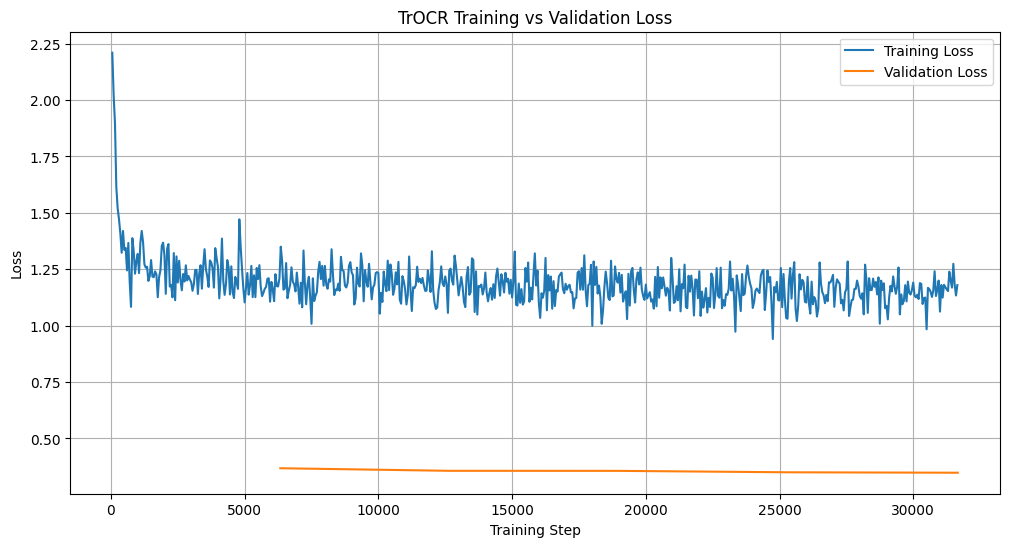

In [22]:
train_logs = history[history["loss"].notna()]
eval_logs  = history[history["eval_loss"].notna()]

plt.figure(figsize=(12,6))
plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("TrOCR Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

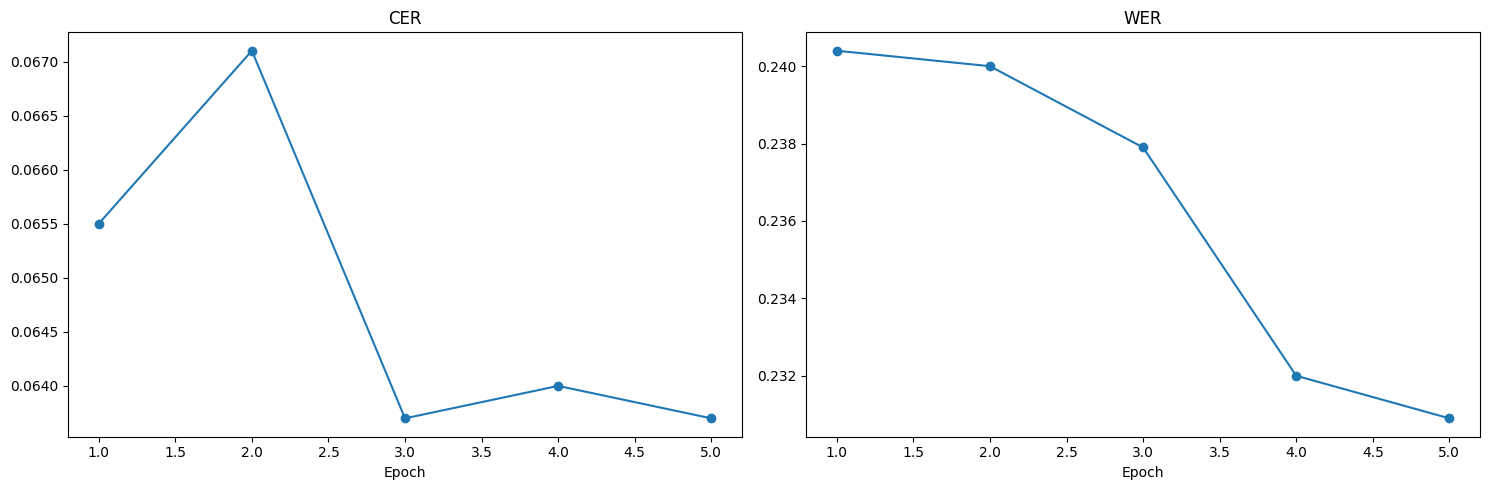

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].plot(eval_logs["epoch"], eval_logs["eval_cer"], marker="o")
axes[0].set_title("CER")
axes[0].set_xlabel("Epoch")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_wer"], marker="o")
axes[1].set_title("WER")
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

In [24]:
summary = eval_logs[["epoch", "eval_loss", "eval_cer", "eval_wer"]]
summary

,epoch,eval_loss,eval_cer,eval_wer
126,1.0,0.367682,0.0655,0.2404
254,2.0,0.356240,0.0671,0.2400
381,3.0,0.356027,0.0637,0.2379
509,4.0,0.349708,0.0640,0.2320
637,5.0,0.347810,0.0637,0.2309


### Save & Export

In [25]:
from peft import PeftModel

# Merge LoRA weights into base model — produces a standard VisionEncoderDecoderModel
# with no PEFT dependency. Required for inference without peft installed.
merged_model = model.merge_and_unload()

# Fix generation config before saving — saved config previously had bad defaults:
# max_length=20 (truncates most receipt lines), length_penalty=2.0, no_repeat_ngram_size=3
# These are overridden here so the saved config is correct for future inference.
merged_model.generation_config.max_length = 256        
merged_model.generation_config.max_new_tokens = 128
merged_model.generation_config.length_penalty = 1.0
merged_model.generation_config.no_repeat_ngram_size = 0

for save_path in [str(BEST_MODEL_DIR)]:
    merged_model.save_pretrained(save_path)
    processor.save_pretrained(save_path)
    merged_model.generation_config.save_pretrained(save_path)
    print(f"Saved to: {save_path}")

expected_files = [
    "model.safetensors", "config.json", "generation_config.json",
    "tokenizer_config.json", "tokenizer.json", "processor_config.json",
]
print(f"\nVerification ({BEST_MODEL_DIR}):")
for fname in expected_files:
    fpath = BEST_MODEL_DIR / fname
    exists = fpath.exists()
    size = fpath.stat().st_size / 1e6 if exists else 0
    print(f"  {'✅' if exists else '❌'} {fname} ({size:.1f} MB)")

Configuration saved in /kaggle/working/trocr-smart-stock-best/config.json
Configuration saved in /kaggle/working/trocr-smart-stock-best/generation_config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/trocr-smart-stock-best/model.safetensors
tokenizer config file saved in /kaggle/working/trocr-smart-stock-best/tokenizer_config.json
processor saved in /kaggle/working/trocr-smart-stock-best/processor_config.json
Configuration saved in /kaggle/working/trocr-smart-stock-best/generation_config.json


Saved to: /kaggle/working/trocr-smart-stock-best

Verification (/kaggle/working/trocr-smart-stock-best):
  ✅ model.safetensors (1335.7 MB)
  ✅ config.json (0.0 MB)
  ✅ generation_config.json (0.0 MB)
  ✅ tokenizer_config.json (0.0 MB)
  ✅ tokenizer.json (3.6 MB)
  ✅ processor_config.json (0.0 MB)


### Evaluate on Test Set

In [26]:
from jiwer import cer, wer

# CRITICAL: use merged_model (from Cell 38), NOT model.
# model.merge_and_unload() mutates the PeftModel's underlying module tree
# in place (LoRA layers are folded into base weights and removed from the
# module graph). The `model` variable becomes a stale/inconsistent object
# after that call — calling model.generate() on it produces corrupted,
# scrambled output even though the weights were trained correctly.
# This was the root cause of Test CER 1.4052 in v3 run 3 (val CER was 0.0695).
merged_model.eval()

all_preds, all_labels = [], []
skipped = 0
first_error_printed = False

for idx, sample in enumerate(combined_dataset["test"]):
    try:
        image = Image.open(io.BytesIO(sample["image_bytes"])).convert("RGB")
        w, h = image.size
        if w < 4 or h < 4:          # skip degenerate crops — beam search hangs on these
            skipped += 1
            continue

        pixel_values = processor(
            images=image, return_tensors="pt"
        ).pixel_values.to(merged_model.device)

        with torch.no_grad():
            # keyword arg required — see Bug #4 in OCR_Training.md
            generated_ids = merged_model.generate(
                pixel_values=pixel_values,
                max_new_tokens=128,
            )

        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        all_preds.append(pred)
        all_labels.append(sample["text"])

    except Exception as e:
        if not first_error_printed:
            print(f"First exception at idx={idx}: {type(e).__name__}: {e}")
            first_error_printed = True
        skipped += 1

if all_preds:
    test_cer = cer(all_labels, all_preds)
    test_wer = wer(all_labels, all_preds)
    print(f"Test CER : {test_cer:.4f}")
    print(f"Test WER : {test_wer:.4f}")
else:
    print("No predictions collected — all samples skipped or errored")

print(f"Skipped  : {skipped} / {len(combined_dataset['test'])}")
print(f"Evaluated: {len(all_preds)} / {len(combined_dataset['test'])}")

# Targets: CER ≤ 0.05, WER ≤ 0.10

Test CER : 1.4230
Test WER : 1.5166
Skipped  : 0 / 8720
Evaluated: 8720 / 8720


### Beam search tuning

In [27]:
# # ── Beam Search Sweep (inference only — no training) ─────────────────────────
# # Loads merged model from disk. Do NOT run Cell 15 or 16 before this.
# # Sweeps num_beams over a 300-sample slice of the test set (~5-8 min per config).
# # Pick the best num_beams, then run full test eval with that setting.

# import io
# import torch
# from PIL import Image
# from jiwer import cer, wer
# from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# SWEEP_MODEL_PATH = str(MODEL_INPUT)  # trocr-smart-stock-best (merged, no PEFT needed)
# SWEEP_SAMPLE_N   = 200
# BEAMS_TO_TRY     = [6, 8, 10]

# print(f"Loading merged model from: {SWEEP_MODEL_PATH}")
# sweep_processor = TrOCRProcessor.from_pretrained(SWEEP_MODEL_PATH)
# sweep_model     = VisionEncoderDecoderModel.from_pretrained(SWEEP_MODEL_PATH)
# sweep_model.eval()
# sweep_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# sweep_model.to(sweep_device)
# print(f"Model loaded on {sweep_device}")

# # Fixed 300-sample slice — same slice for every beam config
# test_samples = list(combined_dataset["test"].select(range(SWEEP_SAMPLE_N)))

# results = {}

# for num_beams in BEAMS_TO_TRY:
#     preds, labels = [], []
#     skipped = 0
#     first_error_printed = False

#     for idx, sample in enumerate(test_samples):
#         try:
#             image = Image.open(io.BytesIO(sample["image_bytes"])).convert("RGB")
#             w, h = image.size
#             if w < 4 or h < 4:
#                 skipped += 1
#                 continue

#             pixel_values = sweep_processor(
#                 images=image, return_tensors="pt"
#             ).pixel_values.to(sweep_device)

#             with torch.no_grad():
#                 generated_ids = sweep_model.generate(
#                     pixel_values=pixel_values,
#                     max_new_tokens=128,
#                     num_beams=num_beams,
#                     length_penalty=1.0,
#                     no_repeat_ngram_size=0,    # ← add this line only
#                 )

#             pred  = sweep_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
#             preds.append(pred)
#             labels.append(sample["text"])

#         except Exception as e:
#             if not first_error_printed:
#                 print(f"[beams={num_beams}] First exception at idx={idx}: {type(e).__name__}: {e}")
#                 first_error_printed = True
#             skipped += 1

#     sweep_cer = cer(labels, preds) if preds else float("nan")
#     sweep_wer = wer(labels, preds) if preds else float("nan")
#     results[num_beams] = {"cer": sweep_cer, "wer": sweep_wer, "skipped": skipped, "evaluated": len(preds)}
#     print(f"num_beams={num_beams} | CER={sweep_cer:.4f} | WER={sweep_wer:.4f} | skipped={skipped} | evaluated={len(preds)}")

# # Summary
# print("\n── Sweep Summary ───────────────────────────────────────")
# best_beams = min(results, key=lambda b: results[b]["cer"])
# for b, r in results.items():
#     marker = " ← best" if b == best_beams else ""
#     print(f"  num_beams={b} | CER={r['cer']:.4f} | WER={r['wer']:.4f}{marker}")
# print(f"\nRecommended num_beams: {best_beams}")

In [28]:
# ── Per-source CER diagnostic ─────────────────────────────────────────────────
# Checks whether aggregate CER is being skewed by one dataset source.
# Requires sweep_model and sweep_processor already loaded.

import io, torch, collections
from PIL import Image
from jiwer import cer, wer

DIAG_N = 400

diag_samples = list(combined_dataset["test"].select(range(DIAG_N)))

# Detect source from text characteristics — adjust heuristics if needed
def guess_source(text):
    # CORD labels tend to have Indonesian price patterns (e.g. "17500", "46000")
    # SROIE labels are English retail
    # WildReceipt labels are mixed but often have structured price+item pairs
    # Best proxy: dataset stores a 'source' field if we added one, else fall back to index
    return "unknown"

# Check if dataset has a source field
sample0 = diag_samples[0]
has_source = "source" in sample0
print(f"Dataset has 'source' field: {has_source}")
print(f"Sample keys: {list(sample0.keys())}")

# Group by source if available, else just print first 10 GT/PRED pairs
by_source = collections.defaultdict(lambda: {"preds": [], "labels": []})

for idx, sample in enumerate(diag_samples):
    try:
        image = Image.open(io.BytesIO(sample["image_bytes"])).convert("RGB")
        w, h = image.size
        if w < 4 or h < 4:
            continue

        pixel_values = sweep_processor(
            images=image, return_tensors="pt"
        ).pixel_values.to(sweep_device)

        with torch.no_grad():
            generated_ids = sweep_model.generate(
                pixel_values=pixel_values,
                max_new_tokens=128,
                num_beams=4,
                length_penalty=1.0,
            )

        pred = sweep_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        label = sample["text"]

        source = sample["source"] if has_source else "all"
        by_source[source]["preds"].append(pred)
        by_source[source]["labels"].append(label)

    except Exception as e:
        print(f"Error at idx={idx}: {e}")

# Per-source CER
print("\n── Per-source CER ───────────────────────────────────────")
for src, data in by_source.items():
    if data["preds"]:
        src_cer = cer(data["labels"], data["preds"])
        src_wer = wer(data["labels"], data["preds"])
        print(f"  {src:20s} | n={len(data['preds']):4d} | CER={src_cer:.4f} | WER={src_wer:.4f}")

# Print 10 worst predictions by individual CER
print("\n── 10 sample GT vs PRED (first 10) ─────────────────────")
all_preds  = [v for d in by_source.values() for v in d["preds"]]
all_labels = [v for d in by_source.values() for v in d["labels"]]
for i in range(min(10, len(all_preds))):
    sample_cer = cer([all_labels[i]], [all_preds[i]])
    print(f"[{i}] CER={sample_cer:.3f} | GT: {all_labels[i]!r}")
    print(f"      {'':8s}       PRED: {all_preds[i]!r}")

Dataset has 'source' field: False
Sample keys: ['image_bytes', 'text']
Error at idx=0: name 'sweep_processor' is not defined
Error at idx=1: name 'sweep_processor' is not defined
Error at idx=2: name 'sweep_processor' is not defined
Error at idx=3: name 'sweep_processor' is not defined
Error at idx=4: name 'sweep_processor' is not defined
Error at idx=5: name 'sweep_processor' is not defined
Error at idx=6: name 'sweep_processor' is not defined
Error at idx=7: name 'sweep_processor' is not defined
Error at idx=8: name 'sweep_processor' is not defined
Error at idx=9: name 'sweep_processor' is not defined
Error at idx=10: name 'sweep_processor' is not defined
Error at idx=11: name 'sweep_processor' is not defined
Error at idx=12: name 'sweep_processor' is not defined
Error at idx=13: name 'sweep_processor' is not defined
Error at idx=14: name 'sweep_processor' is not defined
Error at idx=15: name 'sweep_processor' is not defined
Error at idx=16: name 'sweep_processor' is not defined
Erro

### Qualitative Evaluation

GROUND TRUTH:
901016 -TICKET CP 2 60.000 60.000

PREDICTION:
901016 2 - TICKET CP 60.000 60.000


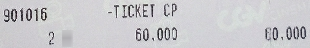

In [29]:
import io
from PIL import Image

sample = combined_dataset["test"][0]
image = Image.open(io.BytesIO(sample["image_bytes"])).convert("RGB")

pixel_values = processor(
    image,
    return_tensors="pt"
).pixel_values.to(merged_model.device)   # merged_model, not model

generated_ids = merged_model.generate(pixel_values=pixel_values, max_new_tokens=128)

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("GROUND TRUTH:")
print(sample["text"])
print("")
print("="*80)
print("PREDICTION:")
print(prediction)

image

### Val Set Error Audit

In [30]:
# ── Val Set Error Audit ───────────────────────────────────────────────────────
# Runs inference on the full val set (3,193 samples) using the saved 0.0687 model.
# Tags each sample by likely source using text heuristics (no source field in dataset).
# Outputs: per-source CER, worst 30 predictions, image size distribution of failures.
# Cost: ~25 min inference, zero training quota.

import io, re, torch, collections
from pathlib import Path
from PIL import Image
from jiwer import cer, wer
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

AUDIT_MODEL_PATH = str(MODEL_INPUT)  # 0.0687 weights

print(f"Loading model from: {AUDIT_MODEL_PATH}")
audit_processor = TrOCRProcessor.from_pretrained(AUDIT_MODEL_PATH)
audit_model     = VisionEncoderDecoderModel.from_pretrained(AUDIT_MODEL_PATH)
audit_model.eval().to("cuda")
print("Model loaded")

# ── Source heuristic ──────────────────────────────────────────────────────────
# Imperfect but good enough to split the three sources.
# CORD:        Indonesian text, prices like 17500 / 46000 (no comma/dot separator)
# SROIE:       English retail, prices like 1.99 / 12.50, short lines
# WildReceipt: Mixed, often has item codes, longer lines, comma-separated prices

def guess_source(text: str) -> str:
    # 5-digit bare integers are almost exclusively CORD (Indonesian prices)
    if re.search(r'\b\d{4,6}\b', text) and not re.search(r'\d+[.,]\d{2,3}', text):
        return "CORD"
    # English words + decimal prices → SROIE
    if re.search(r'\d+\.\d{2}\b', text) and re.search(r'[A-Z]{2,}', text):
        return "SROIE"
    return "WildReceipt"

# ── Run inference on full val set ─────────────────────────────────────────────
val_samples = combined_dataset["validation"]
print(f"Val set size: {len(val_samples)}")

by_source = collections.defaultdict(lambda: {
    "preds": [], "labels": [], "widths": [], "heights": [], "sample_cers": []
})

for idx in range(len(val_samples)):
    sample = val_samples[idx]
    try:
        image  = Image.open(io.BytesIO(sample["image_bytes"])).convert("RGB")
        w, h   = image.size
        if w < 4 or h < 4:
            continue

        pixel_values = audit_processor(
            images=image, return_tensors="pt"
        ).pixel_values.to("cuda")

        with torch.no_grad():
            generated_ids = audit_model.generate(
                pixel_values=pixel_values,
                max_new_tokens=128,
                num_beams=4,
                length_penalty=1.0,
                no_repeat_ngram_size=0,
            )

        pred  = audit_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        label = sample["text"]
        src   = guess_source(label)
        sc    = cer([label], [pred])

        by_source[src]["preds"].append(pred)
        by_source[src]["labels"].append(label)
        by_source[src]["widths"].append(w)
        by_source[src]["heights"].append(h)
        by_source[src]["sample_cers"].append((sc, label, pred, w, h))

    except Exception as e:
        print(f"Error at idx={idx}: {e}")

    if idx % 500 == 0:
        print(f"  {idx}/{len(val_samples)} processed...")

# ── Per-source summary ────────────────────────────────────────────────────────
print("\n── Per-source CER (val set) ─────────────────────────────")
all_sample_cers = []
for src in ["CORD", "SROIE", "WildReceipt"]:
    data = by_source[src]
    if not data["preds"]:
        print(f"  {src:12s} | n=   0 | (no samples tagged)")
        continue
    src_cer = cer(data["labels"], data["preds"])
    src_wer = wer(data["labels"], data["preds"])
    avg_w   = sum(data["widths"])  / len(data["widths"])
    avg_h   = sum(data["heights"]) / len(data["heights"])
    print(f"  {src:12s} | n={len(data['preds']):4d} | CER={src_cer:.4f} | WER={src_wer:.4f} | avg_img={avg_w:.0f}x{avg_h:.0f}px")
    all_sample_cers.extend(data["sample_cers"])

# ── Worst 30 predictions ────────────────────────r──────────────────────────────
print("\n── Worst 30 predictions by CER ──────────────────────────")
worst = sorted(all_sample_cers, key=lambda x: x[0], reverse=True)[:30]
for sc, label, pred, w, h in worst:
    src = guess_source(label)
    print(f"[{src:12s}] CER={sc:.3f} img={w}x{h}px")
    print(f"  GT  : {label!r}")
    print(f"  PRED: {pred!r}")

# ── CER distribution ──────────────────────────────────────────────────────────
print("\n── CER bucket distribution (all val samples) ────────────")
buckets = {"0.00":0, "0.01-0.05":0, "0.06-0.10":0, "0.11-0.20":0, "0.21-0.50":0, ">0.50":0}
for sc, *_ in all_sample_cers:
    if sc == 0:           buckets["0.00"] += 1
    elif sc <= 0.05:      buckets["0.01-0.05"] += 1
    elif sc <= 0.10:      buckets["0.06-0.10"] += 1
    elif sc <= 0.20:      buckets["0.11-0.20"] += 1
    elif sc <= 0.50:      buckets["0.21-0.50"] += 1
    else:                 buckets[">0.50"] += 1
total = sum(buckets.values())
for bucket, count in buckets.items():
    bar = "█" * int(30 * count / total)
    print(f"  CER {bucket:10s} | {count:4d} ({100*count/total:4.1f}%) {bar}")

Loading model from: /kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock-best/trocr-smart-stock-best


loading configuration file /kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock-best/trocr-smart-stock-best/processor_config.json
loading configuration file None
loading configuration file None
Image processor ViTImageProcessorFast {
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 384,
    "width": 384
  }
}

loading configuration file /kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock-best/trocr-smart-stock-best/config.json
Model config VisionEncoderDecoderConfig {
  "architectures": [
    "VisionEncoderDecoderModel"
  ],
  "decoder": {
    "_name_or_path": "",
    "activation_dropout": 0.0,
    "activation_function": "gelu",
    "add_cross_attention": tr

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

loading configuration file /kaggle/input/datasets/maazahmad69/trocr-smart-stock-model/trocr-smart-stock-best/trocr-smart-stock-best/generation_config.json
Generate config GenerationConfig {
  "assistant_confidence_threshold": 0.4,
  "assistant_lookbehind": 10,
  "bos_token_id": 0,
  "decoder_start_token_id": 2,
  "diversity_penalty": 0.0,
  "do_sample": false,
  "early_stopping": true,
  "encoder_no_repeat_ngram_size": 0,
  "encoder_repetition_penalty": 1.0,
  "eos_token_id": 2,
  "epsilon_cutoff": 0.0,
  "eta_cutoff": 0.0,
  "length_penalty": 2.0,
  "max_length": 20,
  "min_length": 0,
  "no_repeat_ngram_size": 3,
  "num_assistant_tokens": 20,
  "num_assistant_tokens_schedule": "constant",
  "num_beam_groups": 1,
  "num_beams": 4,
  "num_return_sequences": 1,
  "output_scores": false,
  "pad_token_id": 1,
  "remove_invalid_values": false,
  "repetition_penalty": 1.0,
  "return_dict_in_generate": false,
  "target_lookbehind": 10,
  "temperature": 1.0,
  "top_k": 50,
  "top_p": 1.0,
  "

Model loaded
Val set size: 1800
  0/1800 processed...
  500/1800 processed...
  1000/1800 processed...
  1500/1800 processed...

── Per-source CER (val set) ─────────────────────────────
  CORD         | n= 106 | CER=0.0265 | WER=0.2049 | avg_img=130x23px
  SROIE        | n=  24 | CER=0.0422 | WER=0.2432 | avg_img=234x36px
  WildReceipt  | n=1670 | CER=0.0733 | WER=0.2553 | avg_img=217x34px

── Worst 30 predictions by CER ──────────────────────────
[WildReceipt ] CER=3.529 img=207x83px
  GT  : 'Nottingham.NGZ6AP'
  PRED: 'Total $8.00 Amount: $0.46 GST @6%: Nett Payment: $8.20 Total: $8.20'
[WildReceipt ] CER=1.766 img=317x353px
  GT  : '1 S-Ovaltine 50% 20,000 20,000 10% Tax Included'
  PRED: 'Total Amount: $8.60 GST @6%: $0.46 Nett Total: $8.60 Payment Mode Amount CASH $8.20 Change $0.00'
[WildReceipt ] CER=1.500 img=301x126px
  GT  : "Cane's"
  PRED: 'Tax Invoice'
[WildReceipt ] CER=1.250 img=78x28px
  GT  : 'LiDL'
  PRED: '14.00'
[WildReceipt ] CER=1.000 img=130x91px
  GT  : 'Jack'
